<a href="https://colab.research.google.com/github/mugalan/introduction-to-statistical-learning/blob/main/assignments/Kalman_filter_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.


---

### Assumptions and Definitions
Before starting, we explicitly define the noise terms typically assumed in these models:
* Process noise: $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$
* Measurement noise: $z_k \sim \mathscr{N}(0, \Sigma_m)$
* $x^{+}_{k-1}$, $w_{k-1}$, and $z_k$ are mutually independent.

---

## 1. Distribution of the Predicted State $x_k^-$

The state prediction equation is:
$$x^{-}_k = A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}$$

Since $x^{-}_k$ is a linear combination of independent Gaussian random variables ($x^{+}_{k-1}$ and $w_{k-1}$), it is also Gaussian. We find its mean and covariance as follows:

### Mean ($m_k^-$):
$$\begin{aligned}
m_k^- = \mathbb{E}[x^{-}_k] &= \mathbb{E}[A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}] \\
&= A_{k-1}\mathbb{E}[x^{+}_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}] \\
&= A_{k-1}m_{k-1} + G_{k-1}(0) \\
&= A_{k-1}m_{k-1}
\end{aligned}$$

### Covariance ($P_k^-$):
$$\begin{aligned}
P_k^- = \text{Var}(x^{-}_k) &= \text{Var}(A_{k-1}x^{+}_{k-1} + G_{k-1}w_{k-1}) \\
&= A_{k-1}\text{Var}(x^{+}_{k-1})A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T \quad \text{(by independence)} \\
&= A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T
\end{aligned}$$

Thus, 
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$$

---

## 2. Distribution of the Predicted Measurement $y_k^-$

The measurement prediction equation is:
$$y^{-}_k = H_k x^{-}_k + z_k$$

Since $x^{-}_k$ and $z_k$ are Gaussian and independent, $y^{-}_k$ is also Gaussian.

### Mean:
$$\begin{aligned}
\mathbb{E}[y^{-}_k] &= \mathbb{E}[H_k x^{-}_k + z_k] \\
&= H_k \mathbb{E}[x^{-}_k] + \mathbb{E}[z_k] \\
&= H_k m_k^- + 0 = H_k m_k^-
\end{aligned}$$

### Covariance:
$$\begin{aligned}
\text{Var}(y^{-}_k) &= \text{Var}(H_k x^{-}_k + z_k) \\
&= H_k \text{Var}(x^{-}_k)H_k^T + \text{Var}(z_k) \quad \text{(by independence)} \\
&= H_k P_k^- H_k^T + \Sigma_m
\end{aligned}$$

Thus,
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$$

---

## 3. Joint Distribution of $\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix}$

Since both variables are linearly dependent on the same underlying Gaussian vectors, they are jointly Gaussian:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left( \mu_{\text{joint}}, \Sigma_{\text{joint}} \right)$$

### Joint Mean:
$$\mu_{\text{joint}} = \begin{bmatrix} \mathbb{E}[x_k^-] \\ \mathbb{E}[y^{-}_k] \end{bmatrix} = \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}$$

### Joint Covariance Block Matrix:
$$\Sigma_{\text{joint}} = \begin{bmatrix} \text{Var}(x_k^-) & \text{Cov}(x_k^-, y_k^-) \\ \text{Cov}(y_k^-, x_k^-) & \text{Var}(y_k^-) \end{bmatrix}$$

We already know the diagonal terms $\text{Var}(x_k^-) = P_k^-$ and $\text{Var}(y_k^-) = H_k P_k^- H_k^T + \Sigma_m$. Let's compute the cross-covariance term:
$$\begin{aligned}
\text{Cov}(x_k^-, y_k^-) &= \mathbb{E}\left[ (x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T \right] \\
&= \mathbb{E}\left[ (x_k^- - m_k^-)(H_k x_k^- + z_k - H_k m_k^-)^T \right] \\
&= \mathbb{E}\left[ (x_k^- - m_k^-)(H_k(x_k^- - m_k^-) + z_k)^T \right] \\
&= \mathbb{E}\left[ (x_k^- - m_k^-)(x_k^- - m_k^-)^T H_k^T \right] + \mathbb{E}\left[ (x_k^- - m_k^-)z_k^T \right] \\
&= P_k^- H_k^T + 0 \quad \text{(since $x_k^-$ and $z_k$ are uncorrelated)}
\end{aligned}$$

Because $\text{Cov}(y_k^-, x_k^-) = \text{Cov}(x_k^-, y_k^-)^T = H_k P_k^-$, we get:
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right)$$

---

## 4. Conditional Distribution (Measurement Update)

To find the conditional distribution of a joint Gaussian distribution $x^{+}_k \triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$, we use the standard linear Gaussian conditioning theorem. 

Given a joint Gaussian system $\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix} \right)$, the conditional distribution $(X \mid Y = y)$ is Gaussian with:
$$\mathbb{E}[X \mid Y=y] = \mu_X + \Sigma_{XY} \Sigma_{YY}^{-1} (y - \mu_Y)$$
$$\text{Var}(X \mid Y=y) = \Sigma_{XX} - \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX}$$

Substituting our blocks from Section 3:
* $\mu_X = m_k^-$
* $\mu_Y = H_k m_k^-$
* $\Sigma_{XX} = P_k^-$
* $\Sigma_{XY} = P_k^- H_k^T$
* $\Sigma_{YY} = H_k P_k^- H_k^T + \Sigma_m$
* $\Sigma_{YX} = H_k P_k^-$

### Defining the Kalman Gain ($K_k$):
$$K_k \triangleq \Sigma_{XY} \Sigma_{YY}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

### Updated Mean ($m_k$):
$$m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

### Updated Covariance ($P_k$):
$$\begin{aligned}
P_k &= P_k^- - K_k \Sigma_{YX} \\
&= P_k^- - K_k H_k P_k^- \\
&= (I - K_k H_k) P_k^-
\end{aligned}$$

Thus, 
$$(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k)$$

---

## 5. Evaluation of Expectations

By definition, the conditional expectation and conditional variance of the state given the observed measurement are precisely the mean and covariance of the updated distribution derived in Section 4.

### Conditional Expectation:
$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

### Conditional Variance:
$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k = (I - K_k H_k) P_k^-$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$


---

## 1-D Kalman Filter Example Derivation

Given the 1-D model:
$$x^-_k = a\,x^+_{k-1} + w_{k-1}, \quad w_{k-1}\sim\mathscr N(0,q)$$
$$y^-_k = h\,x^-_k + z_k, \quad z_k\sim\mathscr N(0,r)$$

---

## 1. Time Update (Prediction Steps)

### Mean ($m_k^-$):
$$\begin{aligned}
m_k^- = \mathbb{E}[x^-_k \mid Y_{k-1}] &= \mathbb{E}[a\,x^+_{k-1} + w_{k-1} \mid Y_{k-1}] \\
&= a\,\mathbb{E}[x^+_{k-1} \mid Y_{k-1}] + \mathbb{E}[w_{k-1}] \\
&= a\,m_{k-1}
\end{aligned}$$

### Covariance ($P_k^-$):
$$\begin{aligned}
P_k^- = \text{Var}(x^-_k \mid Y_{k-1}) &= \text{Var}(a\,x^+_{k-1} + w_{k-1} \mid Y_{k-1}) \\
&= a^2\text{Var}(x^+_{k-1} \mid Y_{k-1}) + \text{Var}(w_{k-1}) \quad \text{(due to independence)} \\
&= a^2 P_{k-1} + q
\end{aligned}$$

---

## 2. Measurement Update (Correction Steps)

Using the scalar form of the Kalman Filter update equations:
* Innovation variance: $S_k = h^2 P_k^- + r$
* Kalman gain: $K_k = \frac{P_k^- h}{S_k} = \frac{P_k^- h}{h^2 P_k^- + r}$

### Updated Mean ($m_k$):
$$m_k = m_k^- + K_k v_k = m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)$$

### Updated Covariance ($P_k$):
$$P_k = (1 - K_k h)P_k^- = \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-$$

---

## 3. Prior Predictive Measurement Distribution $p(y^-_k \mid Y_{k-1})$

Before observing $y^{\mathrm{obs}}_k$, the measurement state is defined by $y^-_k = h\,x^-_k + z_k$. Since $x^-_k \mid Y_{k-1} \sim \mathscr{N}(m_k^-, P_k^-)$, we compute:

* **Mean:** $\mathbb{E}[y^-_k \mid Y_{k-1}] = h\,\mathbb{E}[x^-_k \mid Y_{k-1}] + \mathbb{E}[z_k] = h\,m_k^-$
* **Variance:** $\text{Var}(y^-_k \mid Y_{k-1}) = h^2\text{Var}(x^-_k \mid Y_{k-1}) + \text{Var}(z_k) = h^2 P_k^- + r$

Thus, the prior predictive distribution is:
$$p(y^-_k \mid Y_{k-1}) = \mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$$

---

## 4. Posterior Predictive Measurement Distribution $p(y^-_k \mid Y_k)$

After applying the measurement update step, our knowledge of the underlying state transitions to $x_k \mid Y_k \sim \mathscr{N}(m_k, P_k)$. The measurement framework evaluated at this point remains bounded by $y^-_k = h\,x_k + z_k$:

* **Mean:** $\mathbb{E}[y^-_k \mid Y_k] = h\,\mathbb{E}[x_k \mid Y_k] + \mathbb{E}[z_k] = h\,m_k$
* **Variance:** $\text{Var}(y^-_k \mid Y_k) = h^2\text{Var}(x_k \mid Y_k) + \text{Var}(z_k) = h^2 P_k + r$

Thus, the posterior predictive distribution is:
$$p(y^-_k \mid Y_k) = \mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr)$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.stats import norm
from IPython.display import HTML

# --- 1. Simulation Parameters ---
np.random.seed(42)
T = 30          # Number of time steps
a = 0.95        # State transition parameter
q = 0.2         # Process noise variance
h = 1.0         # Measurement parameter
r = 0.5         # Measurement noise variance

# Prior distribution initial parameters
m0 = 0.0
P0 = 2.0

# --- 2. Generate True States and Observations ---
x_true = np.zeros(T)
y_obs = np.zeros(T)

x_current = np.random.normal(m0, np.sqrt(P0))
for k in range(T):
    w = np.random.normal(0, np.sqrt(q))
    x_true[k] = a * (x_current if k > 0 else x_current) + w
    z = np.random.normal(0, np.sqrt(r))
    y_obs[k] = h * x_true[k] + z
    x_current = x_true[k]

# --- 3. Compute Kalman Filter Vectors ---
m_prior_hist = np.zeros(T)
P_prior_hist = np.zeros(T)
m_post_hist = np.zeros(T)
P_post_hist = np.zeros(T)

m_curr, P_curr = m0, P0

for k in range(T):
    # Time Update (Prior)
    m_prior = a * m_curr
    P_prior = (a**2) * P_curr + q
    
    # Measurement Update (Posterior)
    S = (h**2) * P_prior + r
    K = (P_prior * h) / S
    m_curr = m_prior + K * (y_obs[k] - h * m_prior)
    P_curr = (1 - K * h) * P_prior
    
    m_prior_hist[k] = m_prior
    P_prior_hist[k] = P_prior
    m_post_hist[k] = m_curr
    P_post_hist[k] = P_curr

# --- 4. Animation Assembly ---
fig, ax = plt.subplots(figsize=(10, 6))
x_axis = np.linspace(-5, 5, 1000)

line_prior, = ax.plot([], [], 'r-', lw=2, label='Prior Distribution $p(x_k \\mid Y_{k-1})$')
line_post, = ax.plot([], [], 'b-', lw=2, label='Posterior Distribution $p(x_k \\mid Y_k)$')
vline_true = ax.axvline(0, color='g', linestyle='--', lw=2, label='True State ($x_k$)')
vline_obs = ax.axvline(0, color='k', linestyle=':', lw=1.5, label='Observed Value ($y_k$)')

ax.set_xlim(-5, 5)
ax.set_ylim(0, 1.5)
ax.set_xlabel('State Space ($x$)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Kalman Filter 1-D Distribution Animation', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

def init():
    line_prior.set_data([], [])
    line_post.set_data([], [])
    return line_prior, line_post, vline_true, vline_obs

def update(frame):
    # Calculate Gaussian PDFs
    prior_pdf = norm.pdf(x_axis, m_prior_hist[frame], np.sqrt(P_prior_hist[frame]))
    post_pdf = norm.pdf(x_axis, m_post_hist[frame], np.sqrt(P_post_hist[frame]))
    
    line_prior.set_data(x_axis, prior_pdf)
    line_post.set_data(x_axis, post_pdf)
    
    vline_true.set_xdata([x_true[frame], x_true[frame]])
    vline_obs.set_xdata([y_obs[frame], y_obs[frame]])
    
    ax.set_title(f'Kalman Filter 1-D Distribution Animation (Time Step k = {frame+1}/{T})', fontsize=14)
    return line_prior, line_post, vline_true, vline_obs

anim = FuncAnimation(fig, update, frames=T, init_func=init, blit=True, interval=800)
plt.close()

# Render animation inside Jupyter Notebook cell
HTML(anim.to_jshtml())

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

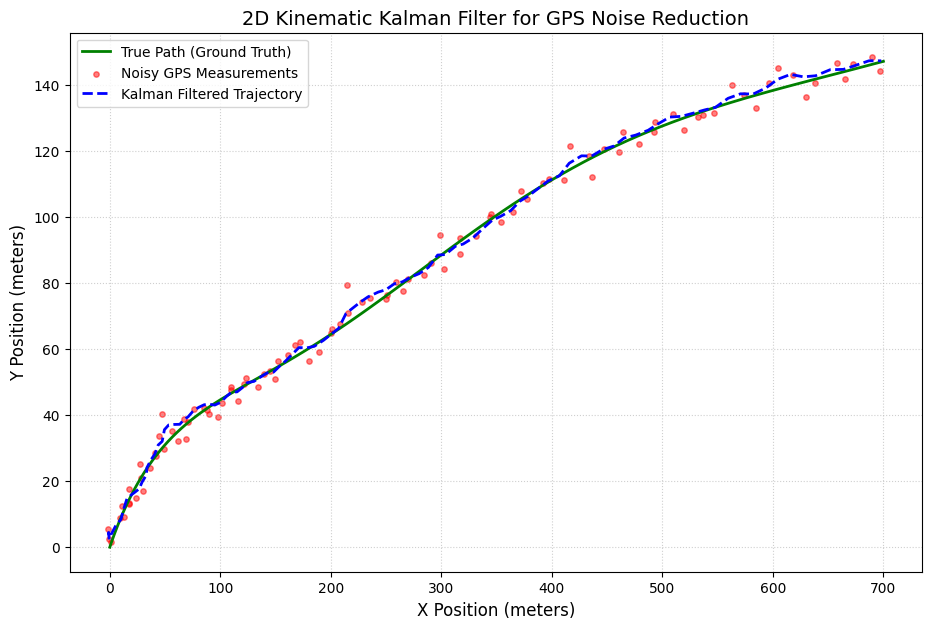

Mean Error Magnitude - Raw GPS     : 3.684 meters
Mean Error Magnitude - Filtered Traj: 2.304 meters


In [3]:
import numpy as np
import matplotlib.pyplot as plt

class GPSKalmanFilter:
    def __init__(self, dt, sigma_a, sigma_g):
        """
        Initializes the 2D Constant Velocity Kalman Filter.
        
        Parameters:
        dt      : float, sampling time interval (seconds)
        sigma_a : float, standard deviation of process acceleration noise
        sigma_g : float, standard deviation of GPS measurement noise
        """
        self.dt = dt
        
        # Initialize State Vector [px, py, vx, vy]^T
        self.x = np.zeros((4, 1))
        
        # Initialize State Covariance Matrix
        self.P = np.eye(4) * 10.0  # high initial uncertainty
        
        # State Transition Matrix (A)
        self.A = np.array([[1.0, 0.0,  dt, 0.0],
                           [0.0, 1.0, 0.0,  dt],
                           [0.0, 0.0, 1.0, 0.0],
                           [0.0, 0.0, 0.0, 1.0]])
        
        # Measurement Matrix (H) - extracts positions px and py
        self.H = np.array([[1.0, 0.0, 0.0, 0.0],
                           [0.0, 1.0, 0.0, 0.0]])
        
        # Process Noise Covariance Matrix (Q)
        dt2 = dt**2
        dt3 = dt**3
        self.Q = (sigma_a**2) * np.array([
            [dt3/3.0, 0.0,     dt2/2.0, 0.0],
            [0.0,     dt3/3.0, 0.0,     dt2/2.0],
            [dt2/2.0, 0.0,     dt,      0.0],
            [0.0,     dt2/2.0, 0.0,     dt]
        ])
        
        # Measurement Noise Covariance Matrix (R)
        self.R = (sigma_g**2) * np.eye(2)
        
        # Identity Matrix
        self.I = np.eye(4)

    def predict(self):
        """Predict step to extrapolate the state forward in time."""
        self.x = np.dot(self.A, self.x)
        self.P = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q
        return self.x

    def update(self, z):
        """
        Update step to correct the prediction using a new GPS measurement.
        
        Parameters:
        z : numpy array of shape (2, 1) containing [measured_px, measured_py]^T
        """
        # Innovation/Residual
        y = z - np.dot(self.H, self.x)
        
        # Innovation Covariance
        S = np.dot(np.dot(self.H, self.P), self.H.T) + self.R
        
        # Kalman Gain
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))
        
        # Post-update state estimate and covariance
        self.x = self.x + np.dot(K, y)
        self.P = np.dot((self.I - np.dot(K, self.H)), self.P)
        return self.x

# --- Simulation and Evaluation Loop ---
if __name__ == "__main__":
    # Time settings
    N = 100          # total data points
    dt = 1.0         # 1 Hz GPS sampling rate
    
    # Noise tuners
    sigma_a = 0.15   # acceleration variation magnitude
    sigma_g = 3.0    # GPS coordinate noise standard deviation (meters)
    
    # 1. Generate Synthetic Ground Truth (a gentle curve path)
    t = np.linspace(0, N*dt, N)
    true_px = 0.5 * 0.1 * t**2 + 2*t   # accelerated curve
    true_py = 5.0 * np.sin(t / 10.0) + 1.5*t
    
    # 2. Corrupt Ground Truth to generate noisy GPS readings
    noise_x = np.random.normal(0, sigma_g, N)
    noise_y = np.random.normal(0, sigma_g, N)
    gps_x = true_px + noise_x
    gps_y = true_py + noise_y
    
    # 3. Apply the Filter
    kf = GPSKalmanFilter(dt=dt, sigma_a=sigma_a, sigma_g=sigma_g)
    
    # Initialize the filter state at the first raw GPS reading
    kf.x = np.array([[gps_x[0]], [gps_y[0]], [0.0], [0.0]])
    
    est_px, est_py = [], []
    
    for i in range(N):
        # Time Step Prediction
        kf.predict()
        
        # Current Measurement Vector
        z = np.array([[gps_x[i]], [gps_y[i]]])
        
        # Correction Step
        updated_state = kf.update(z)
        
        # Record tracked variables
        est_px.append(updated_state[0, 0])
        est_py.append(updated_state[1, 0])
        
    # 4. Plot Comparison Results
    plt.figure(figsize=(11, 7))
    plt.plot(true_px, true_py, 'g-', lw=2, label='True Path (Ground Truth)')
    plt.scatter(gps_x, gps_y, color='red', alpha=0.5, s=15, label='Noisy GPS Measurements')
    plt.plot(est_px, est_py, 'b--', lw=2.0, label='Kalman Filtered Trajectory')
    
    plt.title('2D Kinematic Kalman Filter for GPS Noise Reduction', fontsize=14)
    plt.xlabel('X Position (meters)', fontsize=12)
    plt.ylabel('Y Position (meters)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    
    # Print quantitative performance enhancement
    raw_error = np.mean(np.sqrt((gps_x - true_px)**2 + (gps_y - true_py)**2))
    filtered_error = np.mean(np.sqrt((est_px - true_px)**2 + (est_py - true_py)**2))
    print(f"Mean Error Magnitude - Raw GPS     : {raw_error:.3f} meters")
    print(f"Mean Error Magnitude - Filtered Traj: {filtered_error:.3f} meters")